# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.) I would keep the first plot and cut the second plot because according to the text the trainding data communicates more of a fundamental insight over the estimators. We learned about parameter tuning in another class and I think the second chart speaks more to this than the core understanding of the data which would help ultimately in predictions. Also the second chart shows a very stalled improvement in terms of estimators whereas the first plot shows a longer improvement as the training data is added. 

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

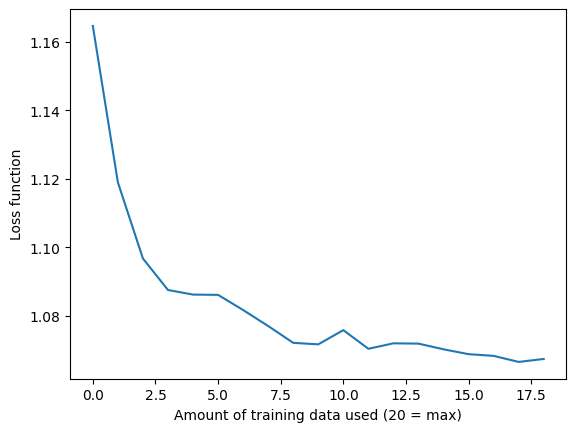

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

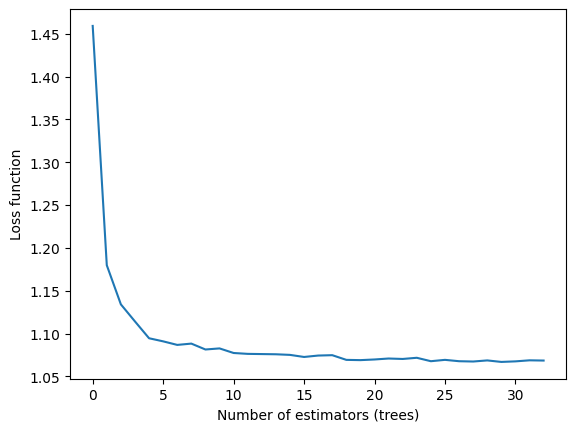

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

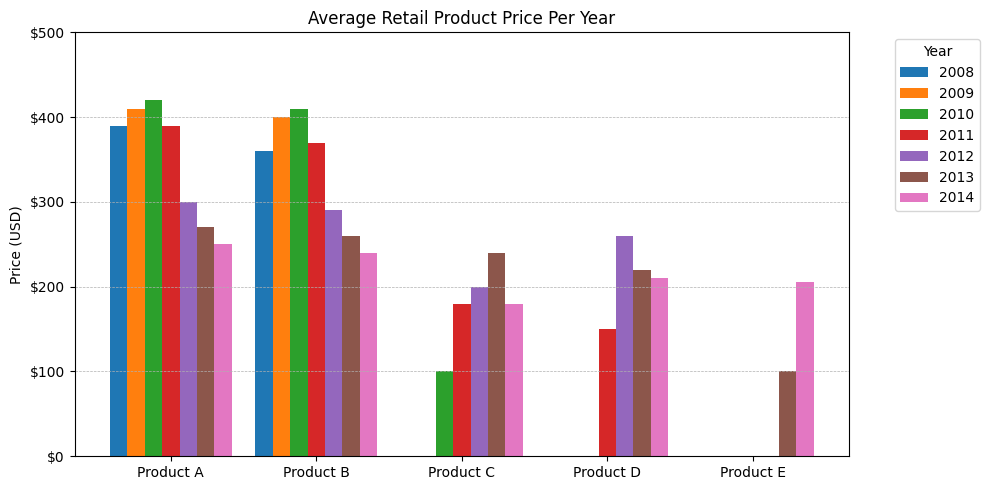

In [7]:
#No chart found, had to go to page 188
years = ["2008", "2009", "2010", "2011", "2012", "2013", "2014"]
products = ["Product A", "Product B", "Product C", "Product D", "Product E"]

values = np.array([
    [390, 410, 420, 390, 300, 270, 250],  # Product A
    [360, 400, 410, 370, 290, 260, 240],  # Product B
    [np.nan, np.nan, 100, 180, 200, 240, 180],  # Product C
    [np.nan, np.nan, np.nan, 150, 260, 220, 210],  # Product D
    [np.nan, np.nan, np.nan, np.nan, np.nan, 100, 205],  # Product E
])


x = np.arange(len(products))
width = 0.12  

fig, ax = plt.subplots(figsize=(10, 5))
for i, year in enumerate(years):
    offset = (i - (len(years)-1)/2) * width
    vals = values[:, i]
    
    mask = ~np.isnan(vals)
    ax.bar(x[mask] + offset, vals[mask], width=width, label=year)


ax.set_ylabel("Price (USD)")
ax.set_title("Average Retail Product Price Per Year")
ax.set_xticks(x)
ax.set_xticklabels(products)
ax.set_ylim(0, 500)
ax.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", linewidth=0.5)


import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout()
plt.show()

